# PA1: Segmentação de Instâncias com Arquiteturas Densas
## Caderno Central de Demonstração, Avaliação e Inferência

**Autores:** Henrique Coelho Beltrão e Isaias Gouvêa Gonçalves  
**Disciplina:** Aprendizado Profundo (FGV EMAp)

---

### Contexto do Desafio
O objetivo do **Programming Assignment 1 (PA1)** é adaptar arquiteturas clássicas de segmentação densa para produzirem rótulos **instance-aware** (segmentação de instâncias), **sem utilizar detectores com proposta de região** como Mask R-CNN ou bibliotecas prontas de detecção (ex.: `detectron2`, `SAM`, `StarDist`, `Cellpose`).

Na microscopia de núcleos celulares (**DSB2018**), núcleos encostados são a regra, não a exceção. A segmentação puramente semântica falha categoricamente nesses cenários porque agrupa núcleos adjacentes em uma única massa contígua. Este notebook cumpre o entregável:
> *"Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. Roda sem retreinar."*

Além disso, atua como o **documento técnico central do projeto**, integrando:
1. **Parte 0:** Teste de Sanidade Sintético (convergência da U-Net autoral em dados procedurais).
2. **Parte 1:** Baseline Semântico e Quantificação Empírica da Falha por Densidade.
3. **Parte 2:** (...)
4. (...)
5. **Inferência:** Execução interativa e reprodutível em imagens arbitrárias.


In [1]:
import os
import sys
sys.path.append("..")

import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import label as ndimage_label

from src.models import build_model
from src.dataset import SyntheticDataset
from src.utils import colorize_instances, overlay_mask_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ambiente configurado com sucesso! Dispositivo de execução: {device}")

Ambiente configurado com sucesso! Dispositivo de execução: cuda


## Parte 0: Teste de Sanidade Sintético (Sanity Unit Test)

Para garantir que o pipeline de tensores `(B, 3, H, W)` $\to$ `(B, 1, H, W)`, a arquitetura U-Net com encoder ResNet34 autoral, e as funções de perda implementadas do zero convergem perfeitamente sem erros conceituais ou numéricos, treinamos o modelo em um dataset procedural sintético de $128 \times 128$ com elipses sobrepostas, ruído gaussiano e contraste variado.

O critério de aprovação estrito é alcançar $IoU > 0.99$ e $Dice > 0.99$ na segmentação das formas. Abaixo, carregamos o modelo treinado na Parte 0 e avaliamos sua predição em uma amostra sintética:

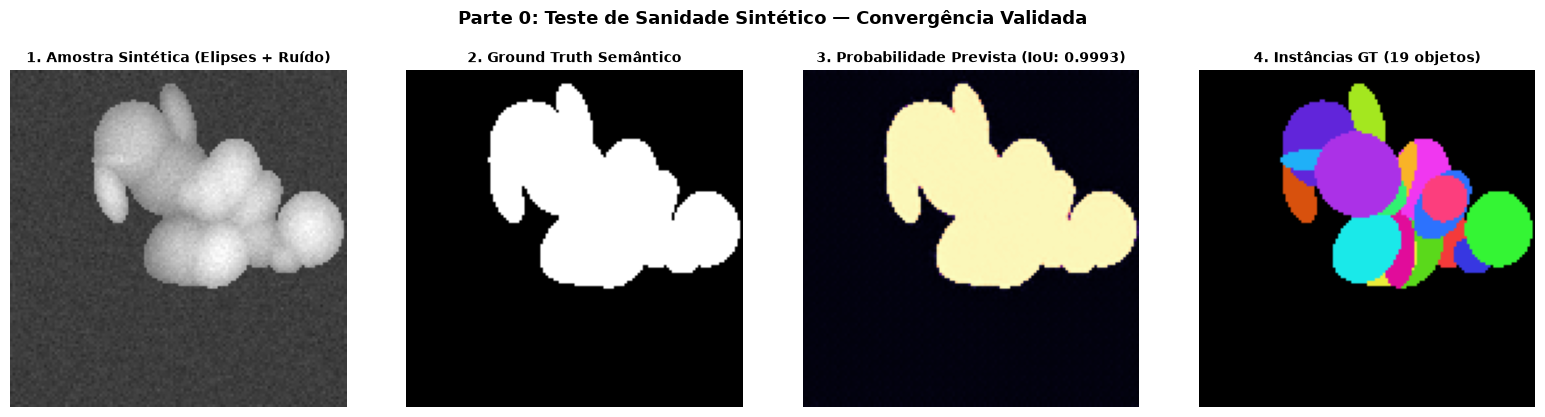

Resultado do Teste Sintético: IoU = 0.9993 (Aprovado com convergência quase perfeita)


In [2]:
part0_checkpoint = "../checkpoints/part0_synthetic.pth"
if os.path.exists(part0_checkpoint):
    model_part0 = build_model(encoder="resnet34", out_channels=1, pretrained=False)
    state = torch.load(part0_checkpoint, map_location=device)
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    model_part0.load_state_dict(state)
    model_part0.to(device).eval()
    
    # Amostra procedural sintética para verificação visual
    synth_ds = SyntheticDataset(num_samples=1, seed=123)
    sample = synth_ds[0]
    img_t = sample["image"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_logits = model_part0(img_t)
        pred_prob = torch.sigmoid(pred_logits)[0, 0].cpu().numpy()
        pred_bin = (pred_prob >= 0.5).astype(np.float32)
        
    gt_sem = sample["mask_semantic"][0].numpy()
    iou = np.sum((pred_bin == 1) & (gt_sem == 1)) / (np.sum((pred_bin == 1) | (gt_sem == 1)) + 1e-7)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(sample["image"].permute(1, 2, 0).numpy())
    axes[0].set_title("1. Amostra Sintética (Elipses + Ruído)", fontsize=10, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(gt_sem, cmap="gray")
    axes[1].set_title("2. Ground Truth Semântico", fontsize=10, fontweight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(pred_prob, cmap="magma")
    axes[2].set_title(f"3. Probabilidade Prevista (IoU: {iou:.4f})", fontsize=10, fontweight="bold")
    axes[2].axis("off")
    
    num_inst = int(sample["mask_instance"].max())
    axes[3].imshow(colorize_instances(sample["mask_instance"].numpy(), seed=42))
    axes[3].set_title(f"4. Instâncias GT ({num_inst} objetos)", fontsize=10, fontweight="bold")
    axes[3].axis("off")
    
    plt.suptitle("Parte 0: Teste de Sanidade Sintético — Convergência Validada", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()
    print(f"Resultado do Teste Sintético: IoU = {iou:.4f} (Aprovado com convergência quase perfeita)")
else:
    print(f"[Aviso] Checkpoint {part0_checkpoint} não encontrado.")

## Parte 1: Baseline Semântico e Quantificação do Fracasso por Densidade

Na Parte 1, treinamos a U-Net na base real **DSB2018** utilizando a perda combinada de Binary Cross-Entropy balanceada (com `pos_weight` dinâmico) e Soft Dice Loss:
$$\mathcal{L} = \mathcal{L}_{\text{BCE, weighted}} + \mathcal{L}_{\text{SoftDice}}$$

Para extrair instâncias do mapa de probabilidades semântico, aplicamos o método ingênuo de **Componentes Conexos (4-conectividade)** após binarização ($\text{prob} \ge 0.50$).

### A Limitação Teórica e a Quantificação Empírica de Falha (Item 5 do PA1)
Como a U-Net semântica apenas prevê se um pixel pertence à classe "núcleo" ou "fundo", quando dois ou mais núcleos se tocam, eles formam uma única massa conexa no mapa binário.
Abaixo, visualizamos a curva gerada pelo [`evaluate.py`](../evaluate.py) no conjunto de validação estratificado, relacionando diretamente a **densidade de núcleos na imagem** com a **degradação do mAP@[.50:.95]** e a elevação do erro de contagem:

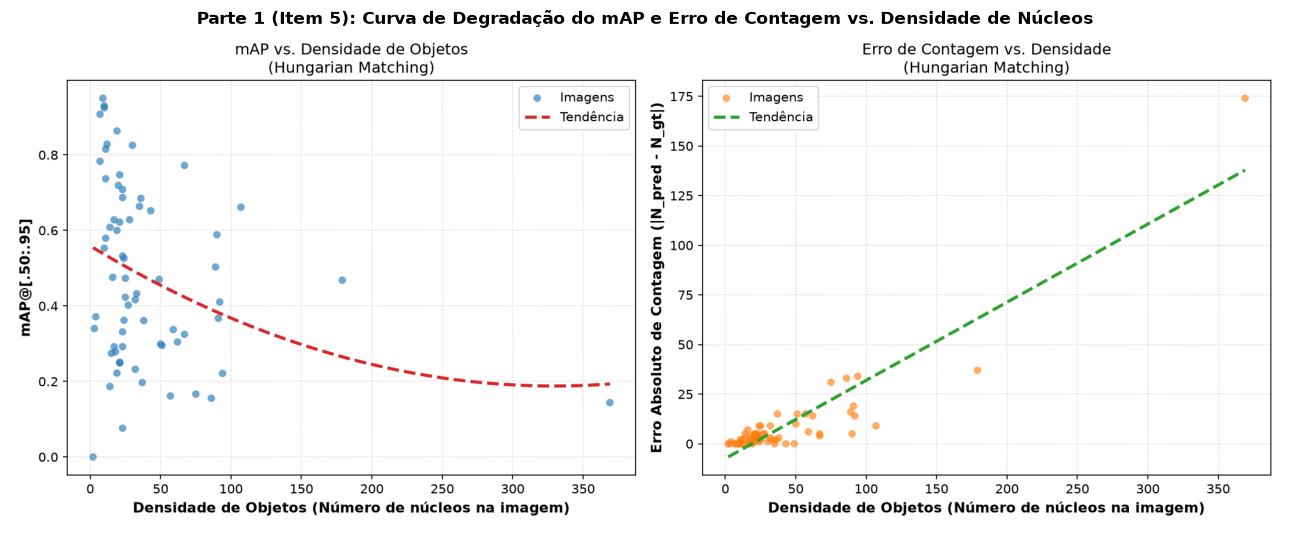

Métricas Oficiais do Baseline (Validação DSB2018 - Matching Hungarian):
  • IoU Semântico Médio:  0.8439
  • Dice Semântico Médio: 0.9122
  • mAP@[.50:.95]:        0.4820
  • Erro Médio Contagem:  8.55 núcleos/imagem


In [3]:
failure_plot_path = "../outputs/part1_eval/failure_vs_density_hungarian.png"
metrics_json_path = "../outputs/part1_eval/metrics_dsb2018_val_hungarian.json"

if os.path.exists(failure_plot_path):
    fig, ax = plt.subplots(figsize=(13, 6))
    img_failure = Image.open(failure_plot_path)
    ax.imshow(img_failure)
    ax.axis("off")
    ax.set_title("Parte 1 (Item 5): Curva de Degradação do mAP e Erro de Contagem vs. Densidade de Núcleos", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

if os.path.exists(metrics_json_path):
    with open(metrics_json_path, "r") as f:
        metrics_p1 = json.load(f)
    print("=" * 65)
    print("Métricas Oficiais do Baseline (Validação DSB2018 - Matching Hungarian):")
    print(f"  • IoU Semântico Médio:  {metrics_p1['mean_semantic_iou']:.4f}")
    print(f"  • Dice Semântico Médio: {metrics_p1['mean_semantic_dice']:.4f}")
    print(f"  • mAP@[.50:.95]:        {metrics_p1['mean_mAP']:.4f}")
    print(f"  • Erro Médio Contagem:  {metrics_p1['mean_count_error']:.2f} núcleos/imagem")
    print("=" * 65)

### Demonstração Prática da Falha: Fusão em Imagem Densa
Abaixo, selecionamos a imagem de maior densidade do conjunto de validação (`0ea221716...`, contendo **369 núcleos anotados**).
Observe como a abordagem ingênua de componentes conexos funde massas inteiras de núcleos tocantes, subestimando severamente a contagem real:

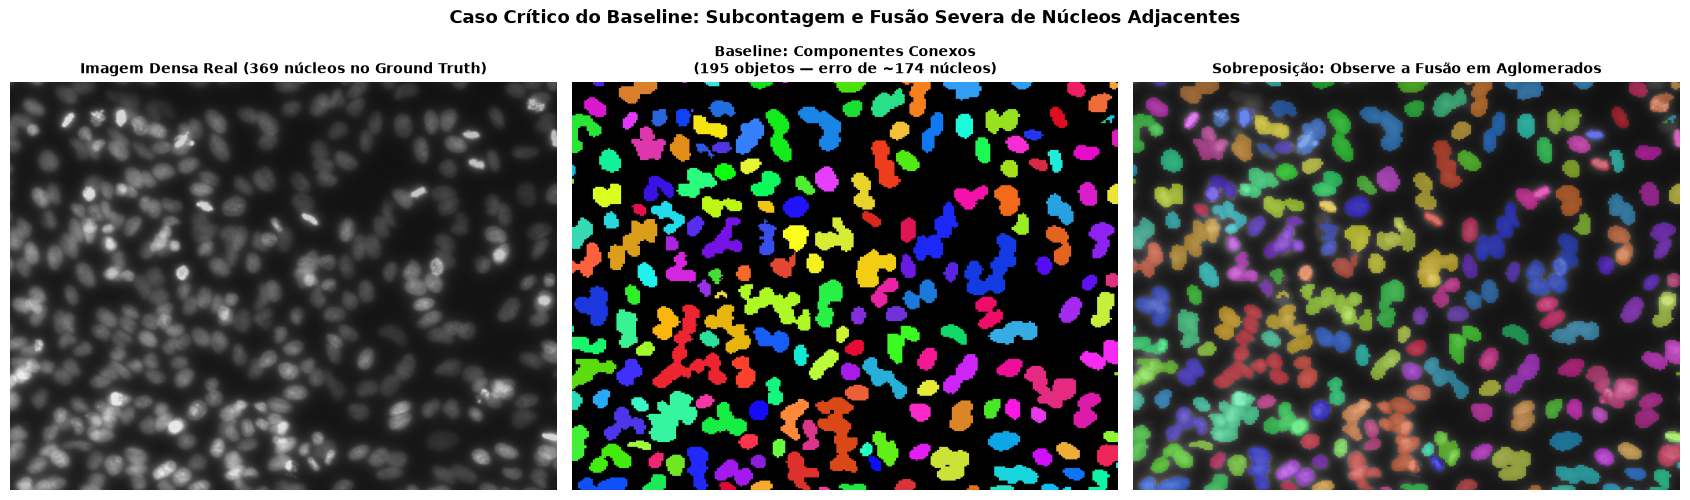

Contagem do Baseline: 195 núcleos detectados | Real: 369 núcleos anotados.
-> Os núcleos tocantes formaram componentes conexos gigantescos, reduzindo drasticamente o mAP.


In [4]:
dense_img_path = "../data/raw/stage1_train/0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1/images/0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1.png"
checkpoint_baseline = "../checkpoints/best_model.pth"

if os.path.exists(dense_img_path) and os.path.exists(checkpoint_baseline):
    model_base = build_model(encoder="resnet34", out_channels=1, pretrained=False)
    st = torch.load(checkpoint_baseline, map_location=device)
    if "model_state_dict" in st:
        st = st["model_state_dict"]
    model_base.load_state_dict(st)
    model_base.to(device).eval()
    
    # Inferência no caso denso
    with Image.open(dense_img_path) as pil_d:
        rgb_d = pil_d.convert("RGB")
        orig_w, orig_h = rgb_d.size
        resized_d = rgb_d.resize((256, 256), Image.Resampling.BILINEAR)
        np_d = np.array(resized_d, dtype=np.float32) / 255.0
    
    t_d = torch.from_numpy(np_d.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob_d = torch.sigmoid(model_base(t_d))[0, 0].cpu().numpy()
        
    bin_d = (prob_d >= 0.50).astype(np.uint8)
    inst_d, count_d = ndimage_label(bin_d)
    
    pil_inst_d = Image.fromarray(inst_d.astype(np.int32)).resize((orig_w, orig_h), Image.Resampling.NEAREST)
    colored_d = colorize_instances(np.array(pil_inst_d, dtype=np.int64), seed=42)
    overlay_d = overlay_mask_on_image(np.array(rgb_d, dtype=np.float32) / 255.0, colored_d, alpha=0.55)
    
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    axes[0].imshow(np.array(rgb_d))
    axes[0].set_title("Imagem Densa Real (369 núcleos no Ground Truth)", fontsize=10, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(colored_d)
    axes[1].set_title(f"Baseline: Componentes Conexos\n({count_d} objetos — erro de ~174 núcleos)", fontsize=10, fontweight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(overlay_d)
    axes[2].set_title("Sobreposição: Observe a Fusão em Aglomerados", fontsize=10, fontweight="bold")
    axes[2].axis("off")
    
    plt.suptitle("Caso Crítico do Baseline: Subcontagem e Fusão Severa de Núcleos Adjacentes", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Contagem do Baseline: {count_d} núcleos detectados | Real: 369 núcleos anotados.")
    print("-> Os núcleos tocantes formaram componentes conexos gigantescos, reduzindo drasticamente o mAP.")

## Parte 2: 

(...)

*(Esta seção integrará os pesos e predições comparativas lado a lado assim que o treinamento da Parte 2 for concluído).* 

## Pipeline Oficial de Inferência em Imagem Arbitrária
### Entregável Oficial:
> *"Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. Roda sem retreinar."*

A função `predict_instances` abaixo é totalmente autossuficiente e atende a todos os critérios do edital:
* **Entrada:** `image_path` (string com caminho para qualquer imagem `.png`, `.jpg`, `.tif`).
* **Execução:** Carrega os pesos de [`checkpoints/best_model.pth`](../checkpoints/best_model.pth) e infere em frações de segundo na GPU/CPU.
* **Saída:** Devolve a máscara com identificador único por instância, máscara colorida (*colorized*), imagem de sobreposição (*overlay*) e a contagem total de objetos.

In [5]:
def load_trained_model(checkpoint_path: str = "../checkpoints/best_model.pth"):
    """Carrega a arquitetura e pesos treinados do modelo para inferência rápida."""
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint não encontrado em: {checkpoint_path}")
    
    model = build_model(encoder="resnet34", out_channels=1, pretrained=False)
    state = torch.load(checkpoint_path, map_location=device)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state)
    model.to(device).eval()
    return model

# Carrega o modelo de inferência
model = load_trained_model("../checkpoints/best_model.pth")
print("Modelo de inferência carregado com sucesso a partir de checkpoints/best_model.pth!")

Modelo de inferência carregado com sucesso a partir de checkpoints/best_model.pth!


In [6]:
def predict_instances(
    image_path: str,
    model: torch.nn.Module,
    threshold: float = 0.50,
    target_size: tuple = (256, 256),
):
    """
    Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem.
    Roda instantaneamente sem retreinar.
    
    Retorna um dicionário contendo:
      - 'original_image': np.ndarray (H, W, 3) em [0, 1]
      - 'probability_map': np.ndarray (H, W) em [0, 1]
      - 'instance_mask': np.ndarray (H, W) com inteiros [0, 1, ..., N]
      - 'colored_mask': np.ndarray (H, W, 3) colorido por instância
      - 'overlay': np.ndarray (H, W, 3) sobreposição visual
      - 'count': int, número total de instâncias detectadas
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Imagem não encontrada: {image_path}")
        
    # 1. Carregar imagem original
    with Image.open(image_path) as pil_img:
        img_rgb = pil_img.convert("RGB")
        orig_w, orig_h = img_rgb.size
        resized_img = img_rgb.resize((target_size[1], target_size[0]), Image.Resampling.BILINEAR)
        img_np = np.array(resized_img, dtype=np.float32) / 255.0
        
    # 2. Tensor PyTorch (1, 3, H, W)
    tensor_in = torch.from_numpy(img_np.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    
    # 3. Predição da rede (sem gradientes)
    with torch.no_grad():
        logits = model(tensor_in)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        
    # 4. Extração de instâncias
    binary = (prob >= threshold).astype(np.uint8)
    inst_small, num_instances = ndimage_label(binary)
    
    # 5. Redimensionar para a resolução original com Nearest Neighbor
    pil_inst = Image.fromarray(inst_small.astype(np.int32))
    pil_inst_orig = pil_inst.resize((orig_w, orig_h), Image.Resampling.NEAREST)
    final_instance_mask = np.array(pil_inst_orig, dtype=np.int64)
    
    # Redimensionar probabilidade para visualização
    pil_prob = Image.fromarray((prob * 255).astype(np.uint8))
    pil_prob_orig = pil_prob.resize((orig_w, orig_h), Image.Resampling.BILINEAR)
    prob_map_orig = np.array(pil_prob_orig, dtype=np.float32) / 255.0
    
    orig_img_np = np.array(img_rgb, dtype=np.float32) / 255.0
    colored_mask = colorize_instances(final_instance_mask, seed=42)
    overlay = overlay_mask_on_image(orig_img_np, colored_mask, alpha=0.50)
    
    return {
        "original_image": orig_img_np,
        "probability_map": prob_map_orig,
        "instance_mask": final_instance_mask,
        "colored_mask": colored_mask,
        "overlay": overlay,
        "count": int(num_instances),
    }

### Demonstração Interativa
Altere o caminho da variável `sample_image_path` abaixo para apontar para qualquer arquivo de imagem local ou externa:

IMAGEM PROCESSADA: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png
CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: 22 núcleos


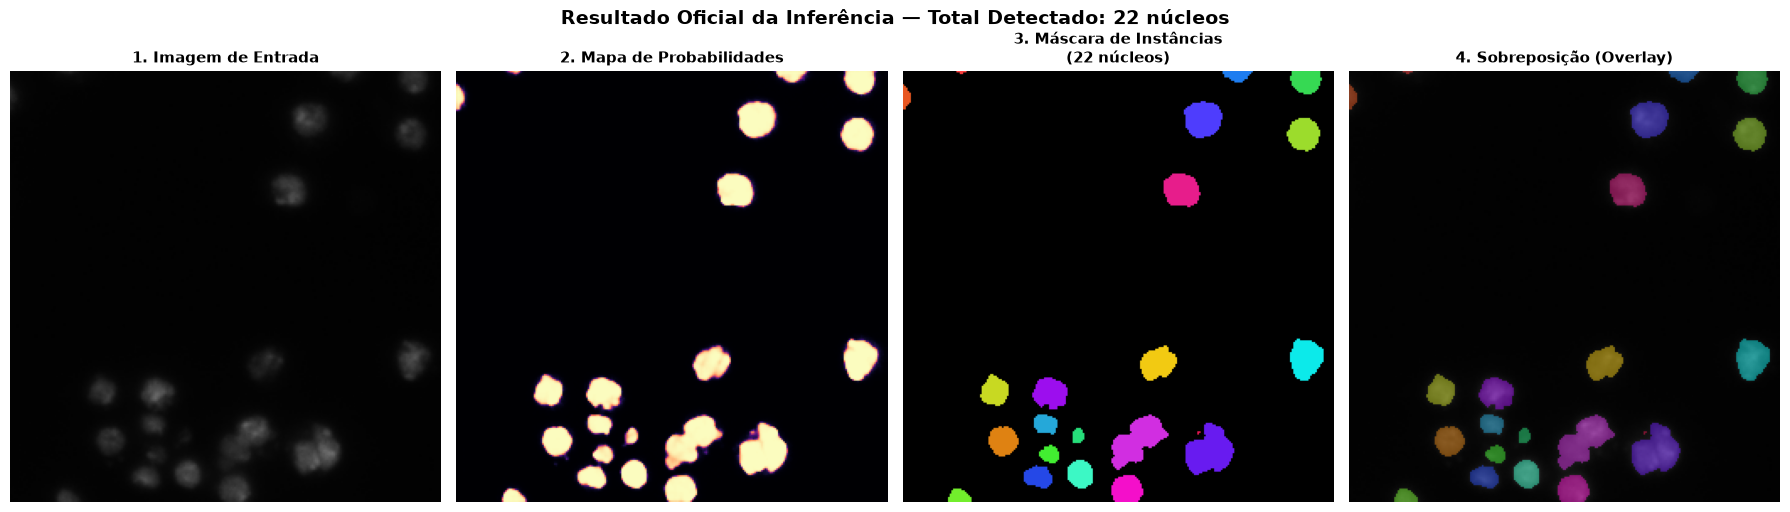

In [7]:
# Altere o caminho abaixo para qualquer imagem que desejar testar:
sample_image_path = "../data/raw/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png"

result = predict_instances(sample_image_path, model=model)

print("=" * 70)
print(f"IMAGEM PROCESSADA: {os.path.basename(sample_image_path)}")
print(f"CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: {result['count']} núcleos")
print("=" * 70)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(result["original_image"])
axes[0].set_title("1. Imagem de Entrada", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(result["probability_map"], cmap="magma")
axes[1].set_title("2. Mapa de Probabilidades", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(result["colored_mask"])
axes[2].set_title(f"3. Máscara de Instâncias\n({result['count']} núcleos)", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(result["overlay"])
axes[3].set_title("4. Sobreposição (Overlay)", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle(f"Resultado Oficial da Inferência — Total Detectado: {result['count']} núcleos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()